In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ── Load data ──────────────────────────────────────────────
cleaned_path = r"D:\Projects\End-to-end projects\10. UPI Payments Intelligence\Data\Cleaned"
exports_path = r"D:\Projects\End-to-end projects\10. UPI Payments Intelligence\Exports"

df          = pd.read_csv(cleaned_path + r"\cleaned_transactions.csv",
                          parse_dates=['txn_datetime','txn_date'])
user_agg    = pd.read_csv(cleaned_path + r"\user_aggregates.csv")
df_users    = pd.read_csv(cleaned_path + r"\cleaned_users.csv")

print(f"✅ Data loaded")
print(f"Transactions:     {len(df):,}")
print(f"User aggregates:  {len(user_agg):,}")

✅ Data loaded
Transactions:     500,000
User aggregates:  10,000


In [2]:
# ── Base features from user_agg ────────────────────────────
features = user_agg[[
    'user_id',
    'total_txns',
    'total_spend',
    'avg_txn_amount',
    'max_txn_amount',
    'unique_merchants',
    'unique_categories',
    'unique_platforms',
    'failed_txns',
    'fraud_txns',
    'cross_city_txns',
    'festival_txns',
    'failure_rate',
    'cross_city_rate',
    'festival_txn_rate',
    'avg_spend_per_day'
]].copy()

# ── Additional behavioral features from transactions ───────
print("Building additional behavioral features...")

# Time preference features
time_pref = df.groupby('user_id').agg(
    evening_txns    = ('txn_id', lambda x: (df.loc[x.index, 'txn_hour'] >= 18).sum()),
    night_txns      = ('txn_id', lambda x: (df.loc[x.index, 'txn_hour'] < 6).sum()),
    weekend_txns    = ('is_weekend', 'sum'),
    morning_txns    = ('txn_id', lambda x: ((df.loc[x.index, 'txn_hour'] >= 6) & 
                                             (df.loc[x.index, 'txn_hour'] < 12)).sum())
).reset_index()

# Category preference features
cat_pref = df.groupby('user_id').agg(
    food_txns       = ('merchant_category', lambda x: (x == 'Food & Beverage').sum()),
    p2p_txns        = ('merchant_category', lambda x: (x == 'P2P Transfer').sum()),
    investment_txns = ('merchant_category', lambda x: (x == 'Investment').sum()),
    ecom_txns       = ('merchant_category', lambda x: (x == 'E-commerce').sum()),
    travel_txns     = ('merchant_category', lambda x: (x == 'Travel').sum())
).reset_index()

# Payment mode preference
mode_pref = df.groupby('user_id').agg(
    qr_txns         = ('payment_mode', lambda x: (x == 'QR Scan').sum()),
    upi_id_txns     = ('payment_mode', lambda x: (x == 'UPI ID').sum())
).reset_index()

# Platform loyalty
plat_loyalty = df.groupby('user_id')['is_preferred_platform'].mean().reset_index()
plat_loyalty.columns = ['user_id', 'platform_loyalty_rate']

# ── Merge all features ─────────────────────────────────────
features = features.merge(time_pref,     on='user_id', how='left')
features = features.merge(cat_pref,      on='user_id', how='left')
features = features.merge(mode_pref,     on='user_id', how='left')
features = features.merge(plat_loyalty,  on='user_id', how='left')

# ── Ratio features ─────────────────────────────────────────
features['evening_ratio']    = (features['evening_txns']    / features['total_txns']).round(4)
features['night_ratio']      = (features['night_txns']      / features['total_txns']).round(4)
features['weekend_ratio']    = (features['weekend_txns']    / features['total_txns']).round(4)
features['food_ratio']       = (features['food_txns']       / features['total_txns']).round(4)
features['p2p_ratio']        = (features['p2p_txns']        / features['total_txns']).round(4)
features['investment_ratio'] = (features['investment_txns'] / features['total_txns']).round(4)
features['ecom_ratio']       = (features['ecom_txns']       / features['total_txns']).round(4)
features['travel_ratio']     = (features['travel_txns']     / features['total_txns']).round(4)
features['qr_ratio']         = (features['qr_txns']         / features['total_txns']).round(4)

features = features.fillna(0)

print(f"✅ Feature matrix built")
print(f"Shape: {features.shape}")
print(f"Features per user: {features.shape[1] - 1}")
print(f"\nFeature columns:")
print([c for c in features.columns if c != 'user_id'])

Building additional behavioral features...
✅ Feature matrix built
Shape: (10000, 37)
Features per user: 36

Feature columns:
['total_txns', 'total_spend', 'avg_txn_amount', 'max_txn_amount', 'unique_merchants', 'unique_categories', 'unique_platforms', 'failed_txns', 'fraud_txns', 'cross_city_txns', 'festival_txns', 'failure_rate', 'cross_city_rate', 'festival_txn_rate', 'avg_spend_per_day', 'evening_txns', 'night_txns', 'weekend_txns', 'morning_txns', 'food_txns', 'p2p_txns', 'investment_txns', 'ecom_txns', 'travel_txns', 'qr_txns', 'upi_id_txns', 'platform_loyalty_rate', 'evening_ratio', 'night_ratio', 'weekend_ratio', 'food_ratio', 'p2p_ratio', 'investment_ratio', 'ecom_ratio', 'travel_ratio', 'qr_ratio']


Feature matrix scaled ✅
Shape: (10000, 19)

Finding optimal clusters (this takes ~1 minute)...


  File "C:\Users\mohsi\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\mohsi\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mohsi\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mohsi\anaconda3\Lib\subprocess.

  k=2 | Inertia: 167,620 | Silhouette: 0.1085
  k=3 | Inertia: 160,557 | Silhouette: 0.0574
  k=4 | Inertia: 155,187 | Silhouette: 0.0579
  k=5 | Inertia: 151,798 | Silhouette: 0.0468
  k=6 | Inertia: 148,913 | Silhouette: 0.0463
  k=7 | Inertia: 146,193 | Silhouette: 0.0471
  k=8 | Inertia: 143,766 | Silhouette: 0.0454
  k=9 | Inertia: 141,707 | Silhouette: 0.0460
  k=10 | Inertia: 139,749 | Silhouette: 0.0444


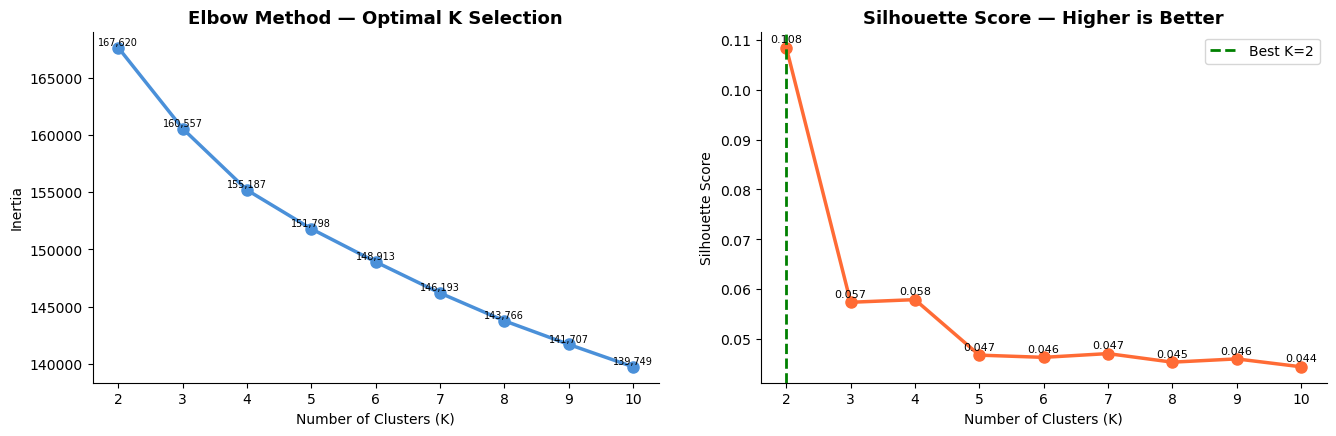


Best K by Silhouette Score: 2
Best Silhouette Score:      0.1085


In [3]:
# ── Select features for clustering ────────────────────────
cluster_features = [
    'avg_txn_amount',
    'total_txns',
    'total_spend',
    'unique_categories',
    'unique_platforms',
    'failure_rate',
    'platform_loyalty_rate',
    'evening_ratio',
    'night_ratio',
    'weekend_ratio',
    'food_ratio',
    'p2p_ratio',
    'investment_ratio',
    'ecom_ratio',
    'travel_ratio',
    'qr_ratio',
    'cross_city_rate',
    'festival_txn_rate',
    'avg_spend_per_day'
]

X = features[cluster_features].copy()

# ── Scale features ─────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix scaled ✅")
print(f"Shape: {X_scaled.shape}")

# ── Elbow method + Silhouette score ───────────────────────
print("\nFinding optimal clusters (this takes ~1 minute)...")

inertias        = []
silhouette_scores = []
k_range         = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, kmeans.labels_, sample_size=3000)
    silhouette_scores.append(score)
    print(f"  k={k} | Inertia: {kmeans.inertia_:,.0f} | Silhouette: {score:.4f}")

# ── Plot elbow + silhouette ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o', linewidth=2.5,
             color='#4A90D9', markersize=8)
axes[0].set_title('Elbow Method — Optimal K Selection',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(k_range))
for k, v in zip(k_range, inertias):
    axes[0].text(k, v + 200, f'{v:,.0f}', ha='center', fontsize=7)

axes[1].plot(k_range, silhouette_scores, marker='o', linewidth=2.5,
             color='#FF6B35', markersize=8)
axes[1].set_title('Silhouette Score — Higher is Better',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(k_range))
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
axes[1].axvline(best_k, color='green', linestyle='--',
                linewidth=2, label=f'Best K={best_k}')
axes[1].legend()
for k, v in zip(k_range, silhouette_scores):
    axes[1].text(k, v + 0.001, f'{v:.3f}', ha='center', fontsize=8)

plt.tight_layout(pad=3)
plt.savefig(exports_path + r"\08_optimal_clusters.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBest K by Silhouette Score: {best_k}")
print(f"Best Silhouette Score:      {max(silhouette_scores):.4f}")

In [4]:
# ── Train final model with K=4 ─────────────────────────────
OPTIMAL_K = 4

kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans_final.fit(X_scaled)

features['segment'] = kmeans_final.labels_

print(f"✅ Clustering complete with K={OPTIMAL_K}")
print(f"\nSegment Distribution:")
print(features['segment'].value_counts().sort_index())

# ── Segment profile ────────────────────────────────────────
segment_profile = features.groupby('segment')[cluster_features].mean().round(2)

print(f"\nSegment Profiles (Mean Values):")
print(segment_profile.T.to_string())

✅ Clustering complete with K=4

Segment Distribution:
segment
0    2885
1    2584
2    2550
3    1981
Name: count, dtype: int64

Segment Profiles (Mean Values):
segment                        0          1          2          3
avg_txn_amount           2875.68    2334.12    3007.46    4022.36
total_txns                 53.33      45.38      48.21      53.49
total_spend            152186.91  104973.80  143737.57  212917.70
unique_categories          16.52      14.90      16.17      16.64
unique_platforms            4.88       4.14       3.38       4.27
failure_rate                5.92       6.04       6.08       6.14
platform_loyalty_rate       0.82       0.84       0.89       0.85
evening_ratio               0.32       0.32       0.32       0.32
night_ratio                 0.04       0.04       0.04       0.03
weekend_ratio               0.29       0.29       0.29       0.29
food_ratio                  0.13       0.16       0.13       0.13
p2p_ratio                   0.05       0.04    

PCA Variance Explained: 26.7%


AttributeError: 'Axes' object has no attribute 'set_theta_offset'

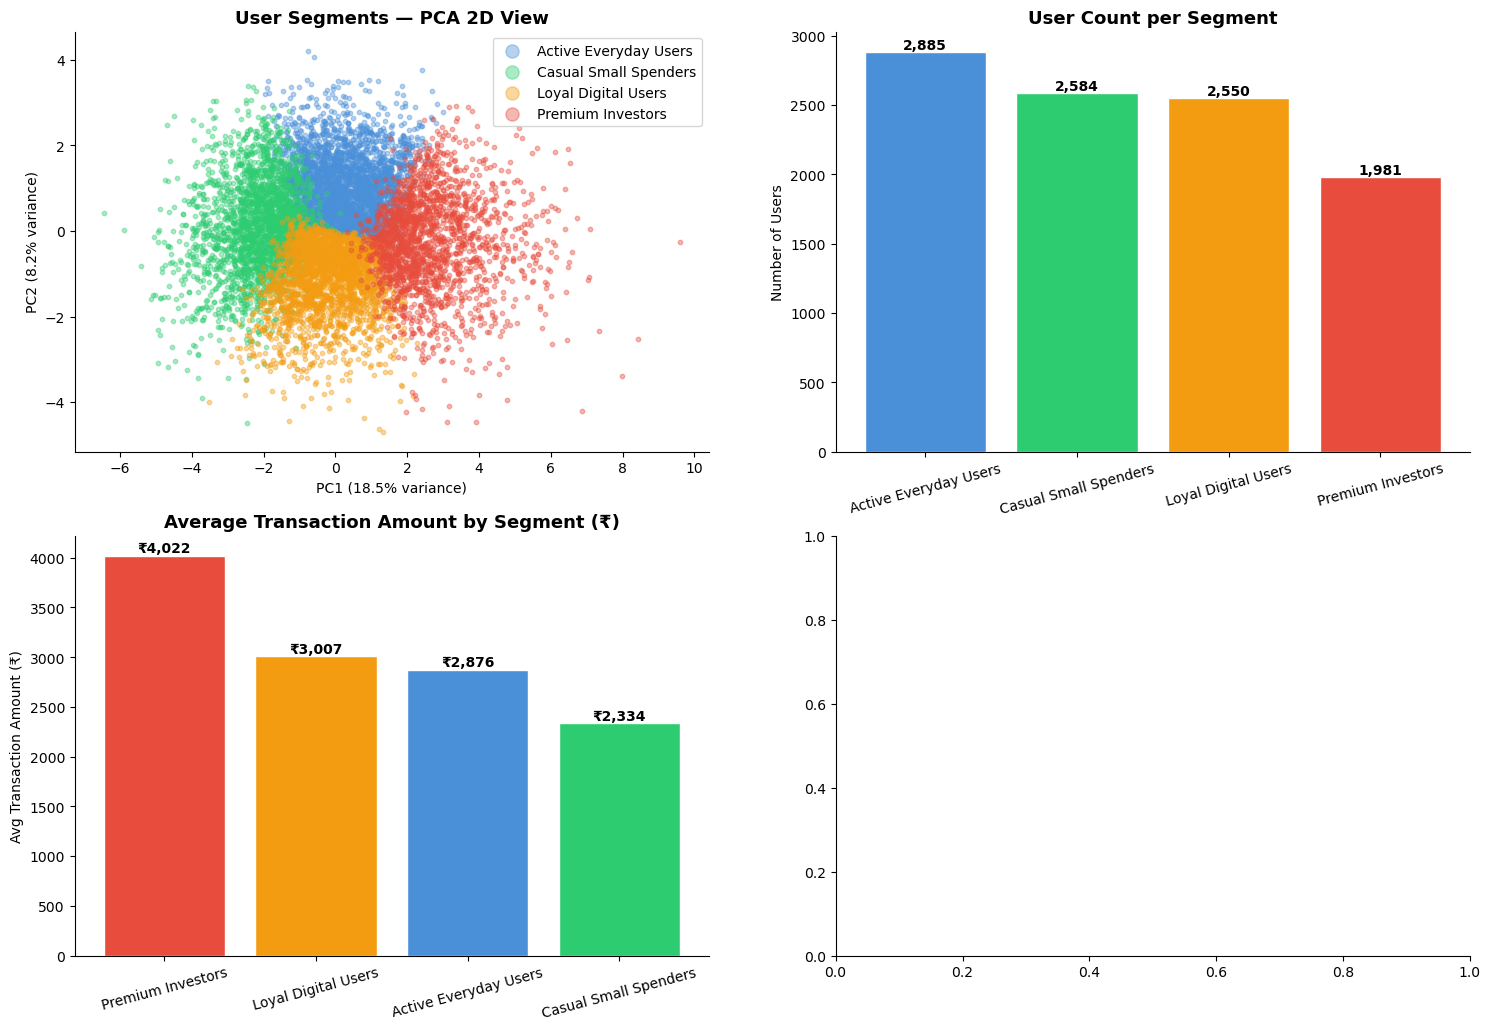

In [5]:
# ── Assign segment names ───────────────────────────────────
segment_names = {
    0: 'Active Everyday Users',
    1: 'Casual Small Spenders',
    2: 'Loyal Digital Users',
    3: 'Premium Investors'
}
segment_colors = {
    'Active Everyday Users': '#4A90D9',
    'Casual Small Spenders': '#2ECC71',
    'Loyal Digital Users':   '#F39C12',
    'Premium Investors':     '#E74C3C'
}

features['segment_name'] = features['segment'].map(segment_names)

# ── PCA for 2D visualization ───────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
features['pca1'] = X_pca[:, 0]
features['pca2'] = X_pca[:, 1]

print(f"PCA Variance Explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── Plot 1: PCA Cluster Visualization ────────────────────
for seg, name in segment_names.items():
    mask = features['segment'] == seg
    axes[0,0].scatter(
        features[mask]['pca1'],
        features[mask]['pca2'],
        label=name, alpha=0.4, s=10,
        color=list(segment_colors.values())[seg]
    )
axes[0,0].set_title('User Segments — PCA 2D View',
                     fontsize=13, fontweight='bold')
axes[0,0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0,0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0,0].legend(markerscale=3)

# ── Plot 2: Segment Size ──────────────────────────────────
seg_counts = features['segment_name'].value_counts()
axes[0,1].bar(
    seg_counts.index,
    seg_counts.values,
    color=[segment_colors[s] for s in seg_counts.index],
    edgecolor='white'
)
axes[0,1].set_title('User Count per Segment',
                     fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('Number of Users')
axes[0,1].tick_params(axis='x', rotation=15)
for i, v in enumerate(seg_counts.values):
    axes[0,1].text(i, v + 20, f'{v:,}', ha='center',
                   fontsize=10, fontweight='bold')

# ── Plot 3: Avg Transaction Amount by Segment ─────────────
seg_avg = features.groupby('segment_name')['avg_txn_amount'].mean().sort_values(ascending=False)
axes[1,0].bar(
    seg_avg.index,
    seg_avg.values,
    color=[segment_colors[s] for s in seg_avg.index],
    edgecolor='white'
)
axes[1,0].set_title('Average Transaction Amount by Segment (₹)',
                     fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Avg Transaction Amount (₹)')
axes[1,0].tick_params(axis='x', rotation=15)
for i, v in enumerate(seg_avg.values):
    axes[1,0].text(i, v + 30, f'₹{v:,.0f}', ha='center',
                   fontsize=10, fontweight='bold')

# ── Plot 4: Radar Chart — Segment Behavioral Profile ──────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

radar_features = [
    'avg_txn_amount', 'total_spend', 'unique_categories',
    'platform_loyalty_rate', 'investment_ratio',
    'food_ratio', 'travel_ratio', 'avg_spend_per_day'
]
radar_labels = [
    'Avg Amount', 'Total Spend', 'Category Diversity',
    'Platform Loyalty', 'Investment %',
    'Food %', 'Travel %', 'Daily Spend'
]

# Normalize 0-1 for radar
radar_data = features.groupby('segment_name')[radar_features].mean()
radar_norm  = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

N = len(radar_features)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

ax_radar = axes[1,1]
ax_radar.set_theta_offset(np.pi / 2)
ax_radar.set_theta_direction(-1)

# Convert to polar
axes[1,1].remove()
ax_radar = fig.add_subplot(2, 2, 4, polar=True)
ax_radar.set_theta_offset(np.pi / 2)
ax_radar.set_theta_direction(-1)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(radar_labels, fontsize=8)
ax_radar.set_ylim(0, 1)
ax_radar.set_title('Behavioral Profile Radar\nby Segment',
                    fontsize=13, fontweight='bold', pad=20)

for seg_name in radar_norm.index:
    values = radar_norm.loc[seg_name].values.tolist()
    values += values[:1]
    ax_radar.plot(angles, values, linewidth=2,
                  label=seg_name, color=segment_colors[seg_name])
    ax_radar.fill(angles, values, alpha=0.1,
                  color=segment_colors[seg_name])

ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)

plt.tight_layout(pad=3)
plt.savefig(exports_path + r"\09_user_segments.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Business Insight ───────────────────────────────────────
print("=" * 60)
print("BUSINESS INSIGHT — USER SEGMENTATION")
print("=" * 60)
seg_summary = features.groupby('segment_name').agg(
    user_count      = ('user_id', 'count'),
    avg_spend       = ('total_spend', 'mean'),
    avg_txn_amount  = ('avg_txn_amount', 'mean'),
    avg_txns        = ('total_txns', 'mean'),
    loyalty_rate    = ('platform_loyalty_rate', 'mean')
).round(2)

print(seg_summary.to_string())
print(f"\nKey Takeaways:")
print(f"Premium Investors are {features[features['segment_name']=='Premium Investors']['avg_txn_amount'].mean() / features[features['segment_name']=='Casual Small Spenders']['avg_txn_amount'].mean():.1f}x higher avg ticket than Casual Small Spenders")
print(f"Loyal Digital Users have highest platform loyalty at {features[features['segment_name']=='Loyal Digital Users']['platform_loyalty_rate'].mean()*100:.1f}%")
print(f"Premium Investors contribute highest daily spend at ₹{features[features['segment_name']=='Premium Investors']['avg_spend_per_day'].mean():,.0f}/day")

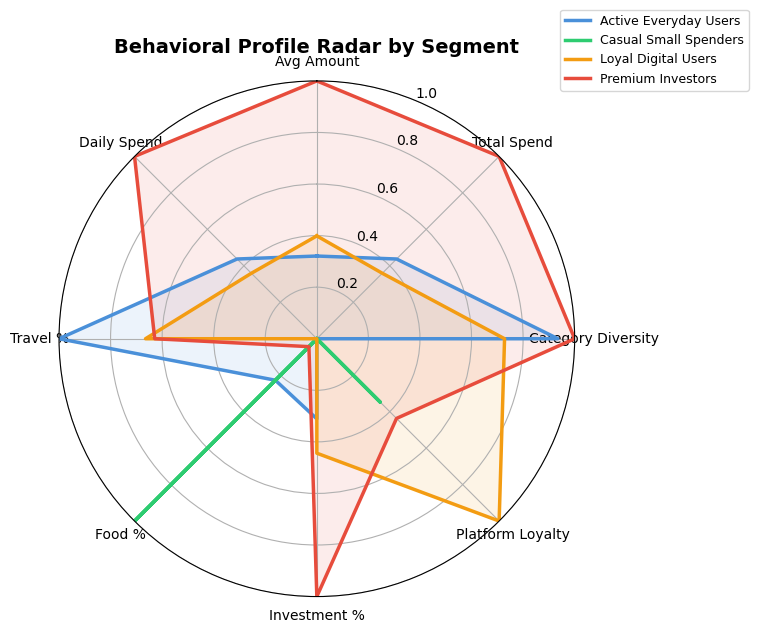

✅ Radar chart saved


In [6]:
# ── Radar Chart — Standalone Fix ──────────────────────────
radar_features = [
    'avg_txn_amount', 'total_spend', 'unique_categories',
    'platform_loyalty_rate', 'investment_ratio',
    'food_ratio', 'travel_ratio', 'avg_spend_per_day'
]
radar_labels = [
    'Avg Amount', 'Total Spend', 'Category Diversity',
    'Platform Loyalty', 'Investment %',
    'Food %', 'Travel %', 'Daily Spend'
]

# Normalize 0-1
radar_data = features.groupby('segment_name')[radar_features].mean()
radar_norm  = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

N      = len(radar_features)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax_radar = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax_radar.set_theta_offset(np.pi / 2)
ax_radar.set_theta_direction(-1)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(radar_labels, fontsize=10)
ax_radar.set_ylim(0, 1)
ax_radar.set_title('Behavioral Profile Radar by Segment',
                    fontsize=14, fontweight='bold', pad=20)

for seg_name in radar_norm.index:
    values = radar_norm.loc[seg_name].values.tolist()
    values += values[:1]
    ax_radar.plot(angles, values, linewidth=2.5,
                  label=seg_name, color=segment_colors[seg_name])
    ax_radar.fill(angles, values, alpha=0.1,
                  color=segment_colors[seg_name])

ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.tight_layout()
plt.savefig(exports_path + r"\09b_radar_chart.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Radar chart saved")

In [7]:
# ── Business Insight ───────────────────────────────────────
print("=" * 60)
print("BUSINESS INSIGHT — USER SEGMENTATION")
print("=" * 60)

seg_summary = features.groupby('segment_name').agg(
    user_count     = ('user_id', 'count'),
    avg_spend      = ('total_spend', 'mean'),
    avg_txn_amount = ('avg_txn_amount', 'mean'),
    avg_txns       = ('total_txns', 'mean'),
    loyalty_rate   = ('platform_loyalty_rate', 'mean'),
    daily_spend    = ('avg_spend_per_day', 'mean')
).round(2)

print(seg_summary.to_string())

# ── Key ratios ─────────────────────────────────────────────
premium_avg  = features[features['segment_name']=='Premium Investors']['avg_txn_amount'].mean()
casual_avg   = features[features['segment_name']=='Casual Small Spenders']['avg_txn_amount'].mean()
loyal_loyalty = features[features['segment_name']=='Loyal Digital Users']['platform_loyalty_rate'].mean()
premium_daily = features[features['segment_name']=='Premium Investors']['avg_spend_per_day'].mean()

print(f"\nKey Takeaways:")
print(f"Premium Investors are {premium_avg/casual_avg:.1f}x higher avg ticket than Casual Small Spenders")
print(f"Loyal Digital Users have highest platform loyalty at {loyal_loyalty*100:.1f}%")
print(f"Premium Investors contribute highest daily spend at ₹{premium_daily:,.0f}/day")

BUSINESS INSIGHT — USER SEGMENTATION
                       user_count  avg_spend  avg_txn_amount  avg_txns  loyalty_rate  daily_spend
segment_name                                                                                     
Active Everyday Users        2885  152186.91         2875.68     53.33          0.82       208.48
Casual Small Spenders        2584  104973.80         2334.12     45.38          0.84       143.80
Loyal Digital Users          2550  143737.57         3007.46     48.21          0.89       196.90
Premium Investors            1981  212917.70         4022.36     53.49          0.85       291.67

Key Takeaways:
Premium Investors are 1.7x higher avg ticket than Casual Small Spenders
Loyal Digital Users have highest platform loyalty at 89.5%
Premium Investors contribute highest daily spend at ₹292/day


In [8]:
# ── Merge segment back to users ────────────────────────────
df_users_segmented = df_users.merge(
    features[['user_id', 'segment', 'segment_name',
              'avg_txn_amount', 'total_spend', 'total_txns',
              'platform_loyalty_rate', 'avg_spend_per_day',
              'pca1', 'pca2']],
    on='user_id', how='left'
)

# ── Save ───────────────────────────────────────────────────
df_users_segmented.to_csv(
    cleaned_path + r"\users_segmented.csv", index=False
)
features.to_csv(
    cleaned_path + r"\user_features_clustered.csv", index=False
)

print(f"✅ Segmented users saved: {len(df_users_segmented):,} rows")
print(f"✅ Feature matrix saved:  {len(features):,} rows")
print(f"\nSegment distribution saved:")
print(df_users_segmented['segment_name'].value_counts())
print(f"\nColumns in segmented users file:")
print(df_users_segmented.columns.tolist())

✅ Segmented users saved: 10,000 rows
✅ Feature matrix saved:  10,000 rows

Segment distribution saved:
segment_name
Active Everyday Users    2885
Casual Small Spenders    2584
Loyal Digital Users      2550
Premium Investors        1981
Name: count, dtype: int64

Columns in segmented users file:
['user_id', 'age', 'gender', 'city', 'city_tier', 'preferred_platform', 'activity_level', 'monthly_txn_frequency', 'device_type', 'registration_date', 'segment', 'segment_name', 'avg_txn_amount', 'total_spend', 'total_txns', 'platform_loyalty_rate', 'avg_spend_per_day', 'pca1', 'pca2']
